Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 027
Code Title: | Digital Signal Processing and Application
1st Semester | AY 2026 - 2027
**Name** | Deniega, Alexis Neil D.
**Section** | CPE41S2
**Date Performed**: |
**Date Submitted**: |
**Instructor**: | Engr. Jimlord Quejado

<hr>

## Discussion


## Requirements




## Procedures

### 1. Consider the following discrete-time systems:

a. y[n] = x[n] + x[n + 3]
b. y[n] = x[n] + 7x[n−6]
c. y[n] = x3[n – 2] + 2x[n]
d. y[n] = x[3.5n]






In [1]:
import numpy as np
import matplotlib.pyplot as plt

def system_a(x, n_indices):
    # y[n] = x[n] + x[n + 3]
    y = np.zeros_like(x, dtype=float)
    for i, n in enumerate(n_indices):
        # x[n+3]
        idx_plus_3 = np.where(n_indices == n + 3)[0]
        val_plus_3 = x[idx_plus_3[0]] if len(idx_plus_3) > 0 else 0
        y[i] = x[i] + val_plus_3
    return y

def system_b(x, n_indices):
    # y[n] = x[n] + 7x[n-6]
    y = np.zeros_like(x, dtype=float)
    for i, n in enumerate(n_indices):
        idx_minus_6 = np.where(n_indices == n - 6)[0]
        val_minus_6 = x[idx_minus_6[0]] if len(idx_minus_6) > 0 else 0
        y[i] = x[i] + 7 * val_minus_6
    return y

def system_c(x, n_indices):
    # y[n] = x^3[n-2] + 2x[n]
    y = np.zeros_like(x, dtype=float)
    for i, n in enumerate(n_indices):
        idx_minus_2 = np.where(n_indices == n - 2)[0]
        val_minus_2 = x[idx_minus_2[0]] if len(idx_minus_2) > 0 else 0
        y[i] = (val_minus_2 ** 3) + 2 * x[i]
    return y

def system_d(x, n_indices):
    # y[n] = x[3.5n]
    y = np.zeros_like(x, dtype=float)
    for i, n in enumerate(n_indices):
        target_n = 3.5 * n
        idx = np.where(n_indices == target_n)[0]
        y[i] = x[idx[0]] if len(idx) > 0 else 0
    return y

2. Graph the following systems using the following sequence: x[n] = {8, 2, 4, -3, 1, -5, 4, 7, 0, 2, 1, -6, -1, 0, 2, 1, 9, 6, -4, 5}.







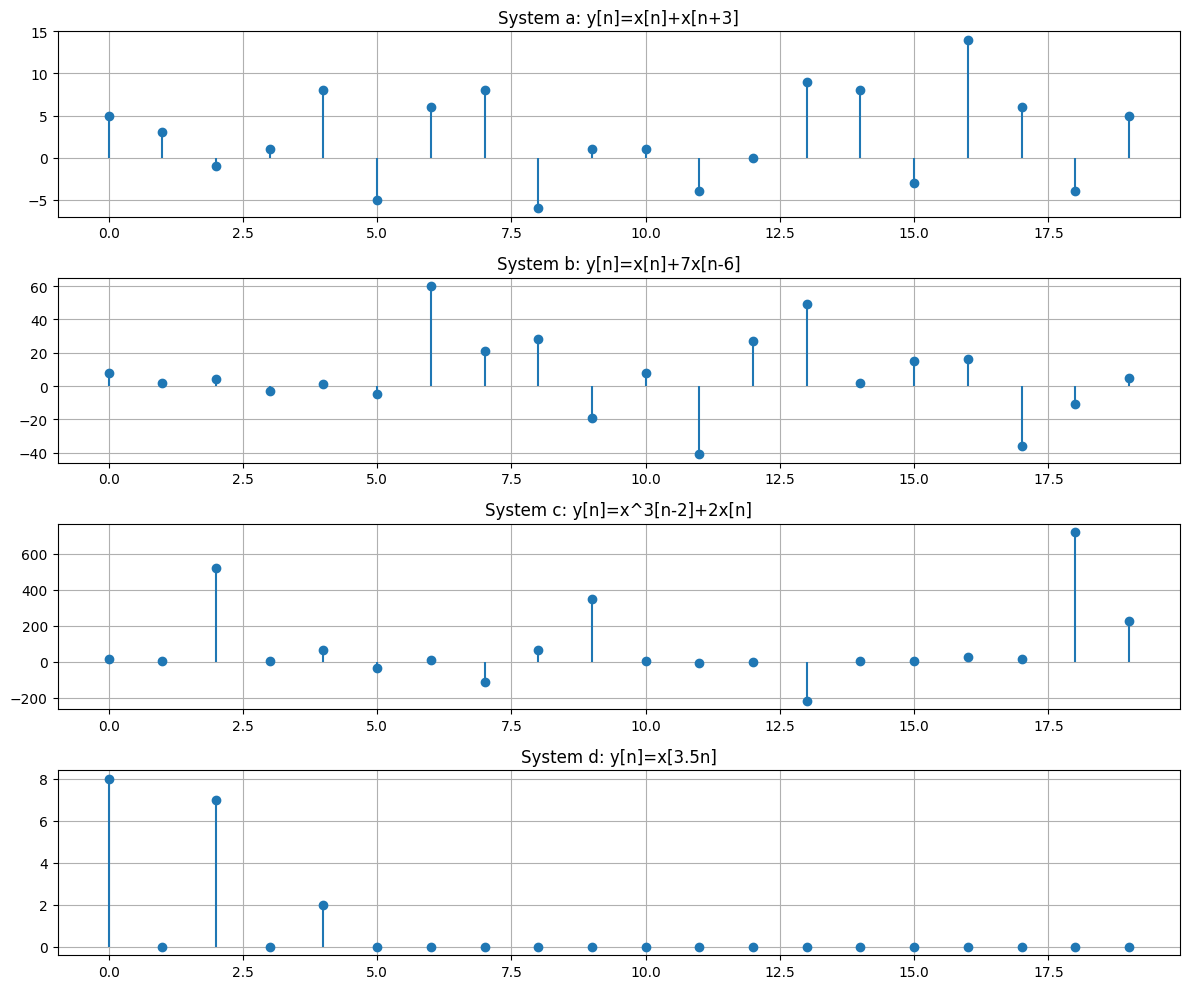

In [2]:
x_seq = np.array([8, 2, 4, -3, 1, -5, 4, 7, 0, 2, 1, -6, -1, 0, 2, 1, 9, 6, -4, 5])
n = np.arange(len(x_seq))

systems = [system_a, system_b, system_c, system_d]
labels = ['y[n]=x[n]+x[n+3]', 'y[n]=x[n]+7x[n-6]', 'y[n]=x^3[n-2]+2x[n]', 'y[n]=x[3.5n]']

plt.figure(figsize=(12, 10))
for i, sys_func in enumerate(systems):
    plt.subplot(4, 1, i+1)
    plt.stem(n, sys_func(x_seq, n), basefmt=" ")
    plt.title(f'System {chr(97+i)}: {labels[i]}')
    plt.grid(True)
plt.tight_layout()
plt.show()

3. Using the Principle of Superposition, determine analytically and graphically whether these systems are linear. Use the values 4 and 7 for constants a1 and a2 respectively.






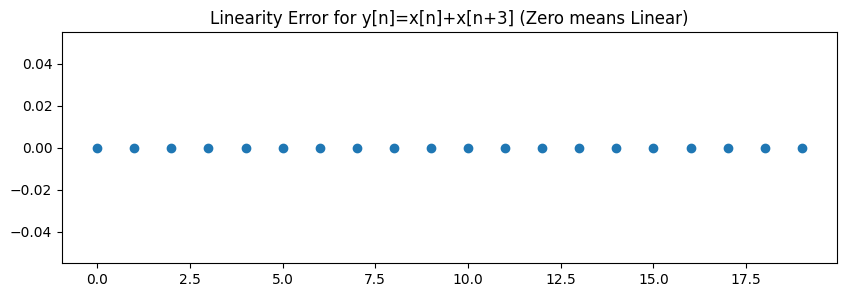

y[n]=x[n]+x[n+3] is Linear


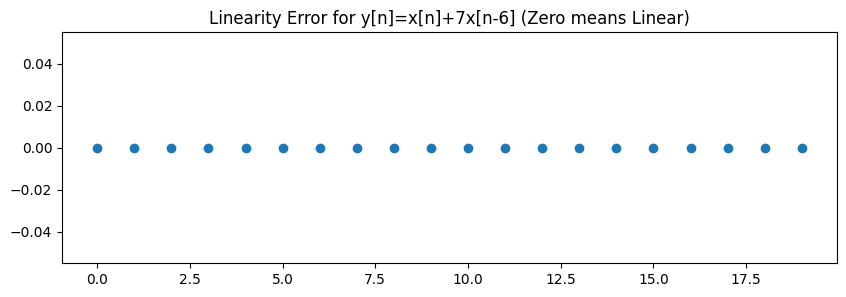

y[n]=x[n]+7x[n-6] is Linear


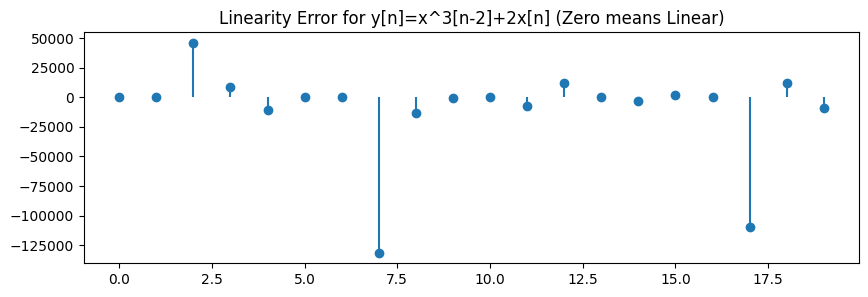

y[n]=x^3[n-2]+2x[n] is Non-Linear


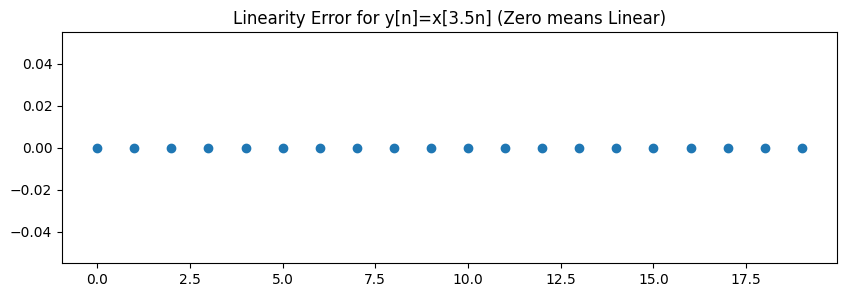

y[n]=x[3.5n] is Linear


In [3]:
a1, a2 = 4, 7
x1 = np.random.randint(-5, 5, len(x_seq))
x2 = np.random.randint(-5, 5, len(x_seq))

def check_linearity(sys_func, name):
    y_combined_input = sys_func(a1*x1 + a2*x2, n)
    y_combined_output = a1*sys_func(x1, n) + a2*sys_func(x2, n)

    is_linear = np.allclose(y_combined_input, y_combined_output)

    plt.figure(figsize=(10, 3))
    plt.stem(n, y_combined_input - y_combined_output, basefmt=" ")
    plt.title(f"Linearity Error for {name} (Zero means Linear)")
    plt.show()
    print(f"{name} is {'Linear' if is_linear else 'Non-Linear'}")

for i, sys_func in enumerate(systems):
    check_linearity(sys_func, labels[i])

4. Then identify if the systems are time-invariant, static or causal.

### System Analysis Summary

| System | Linear | Time-Invariant | Static/Dynamic | Causal/Non-Causal |
|---|---|---|---|---|
| **a. y[n] = x[n] + x[n+3]** | Yes | Yes | Dynamic (needs n+3) | Non-Causal (looks ahead) |
| **b. y[n] = x[n] + 7x[n-6]** | Yes | Yes | Dynamic (needs n-6) | Causal (looks back) |
| **c. y[n] = x³[n-2] + 2x[n]** | No (Cube term) | Yes | Dynamic (needs n-2) | Causal |
| **d. y[n] = x[3.5n]** | Yes | No (Scaling n) | Dynamic | Non-Causal (for n > 0) |